In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
# !pip install -e SPICE

In [3]:
import sys
import torch

from spice import SpiceEstimator, csv_to_dataset, split_data_along_blockdim, BaseModel
from spice.precoded import workingmemory

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from benchmarking_dezfouli2019 import GQLModel, get_dataset, generate_behavior

from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from analysis_generative import analysis_generative_behavior

# NOTEBOOK CONFIG

In [4]:
train_spice = False
train_gql = False
train_gru = False

## Load dataset

In [5]:
path_data = 'data/dezfouli2019.csv'
test_blocks = (3, 6, 9)
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_blocks=test_blocks, verbose=True)

Shape of dataset: torch.Size([1212, 202, 1, 9])
Number of participants: 101
Number of actions in dataset: 2


## SPICE Training

Let's setup now the `SpiceEstimator` object and fit it to the data! 

We are going to do this in two steps:

1. Without fitting the SINDy coefficients to get the pure RNN performance given the selected architecture. 
2. With fitting SINDy coefficients to get the final performance of the interpretable model

That way we can disentangle the gap between GRU and SPICE w.r.t. architecture and SINDy library 

In [6]:
path_spice = 'params/spice_dezfouli2019.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=workingmemory.SpiceModel,
        spice_config=workingmemory.CONFIG,
        n_actions=info_dataset['n_actions'],
        n_participants=info_dataset['n_participants'],
        kwargs_spice_class={'reward_binary': True},
        
        epochs=1000,
        warmup_steps=250,
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        verbose=True,
        save_path_spice=path_spice,
    )

In [7]:
if train_spice:
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_train.xs, dataset_train.ys)

In [8]:
estimator.load_spice(path_spice)

In [9]:
# Print example SPICE model for first participant
print("\nExample SPICE model (participant 0):")
estimator.print_spice_model(participant_id=0)


Example SPICE model (participant 0):
value_reward_chosen[t+1]     = 0.116 1 + 0.816 value_reward_chosen[t] + -0.589 reward[t] + 0.488 reward[t-1] + 0.23 reward[t-2] + 0.113 reward[t-3] + 0.002 value_reward_chosen^2 + 0.173 value_reward_chosen*reward[t] + -0.049 value_reward_chosen*reward[t-1] + -0.007 value_reward_chosen*reward[t-2] + -0.05 value_reward_chosen*reward[t-3] + -0.355 reward[t]^2 + 0.078 reward[t]*reward[t-2] + 0.148 reward[t]*reward[t-3] + 0.297 reward[t-1]^2 + -0.072 reward[t-1]*reward[t-3] + 0.177 reward[t-2]^2 + 0.145 reward[t-3]^2 
value_reward_not_chosen[t+1] = -0.323 1 + 0.526 value_reward_not_chosen[t] + -0.116 reward[t-1] + -0.019 reward[t-2] + -0.063 value_reward_not_chosen^2 + -0.054 value_reward_not_chosen*reward[t-1] + -0.011 value_reward_not_chosen*reward[t-2] 
value_choice_chosen[t+1]     = 0.145 1 + 0.644 value_choice_chosen[t] + 0.178 choice[t-1] + -0.475 choice[t-2] + -0.105 choice[t-3] + 0.035 value_choice_chosen^2 + 0.032 value_choice_chosen*choice[t-1

## Benchmarking

### Generalized Q-Learning Model by Dezfouli (2019)

In [10]:
# 1. stick to low effort 
# 2. two sets of params for low and high effort

gql = GQLModel(
    n_participants=info_dataset['n_participants'],
    batch_first=True,
    )

path_gql = path_spice.replace('spice_', 'gql_')

In [11]:
if train_gql:
    epochs = 1000
    optimizer = torch.optim.Adam(params=gql.parameters(), lr=0.01)

    gql = training(
        model=gql,
        optimizer=optimizer,
        epochs=epochs,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        device=torch.device('cpu'),
    )

    torch.save(gql.state_dict(), path_gql)

In [12]:
gql.load_state_dict(torch.load(path_gql, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [13]:
gru = GRUModel(
    n_actions=info_dataset['n_actions'], 
    n_participants=info_dataset['n_participants'],
    additional_inputs=2, 
    dropout=0.25,
    embedding_size=8,
    hidden_size=8,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [14]:
if train_gru:
    epochs = 1000
    optimizer = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru,
        optimizer=optimizer,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        ).to(torch.device('cpu'))

    torch.save(gru.state_dict(), path_gru)

In [15]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

<All keys matched successfully>

# ANALYSIS

In [16]:
estimator.eval()
gql.eval()
gru.eval()

GRUModel(
  (participant_embedding): Embedding(101, 8)
  (experiment_embedding): Embedding(1, 8)
  (linear_in): Linear(in_features=14, out_features=8, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (gru): GRU(8, 8, batch_first=True)
  (linear_out): Linear(in_features=8, out_features=2, bias=True)
)

## Analysis model evaluation

In [17]:
analysis_model_evaluation(
    dataset=dataset_train,
    spice_model=estimator,
    benchmark_model=gql.to(torch.device('cpu')),
    gru_model=gru.to(torch.device('cpu')),
)

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


W0702 12:06:20.963000 64798 site-packages/torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC,ΔBIC/trial
Benchmark,0.718950,0.161177,12.000000,0.000000,32176.376953,64376.753906,64490.605469,0.724954
GRU,0.764675,0.141192,1386.000000,0.000000,26163.677734,55099.355469,68249.390625,0.686408
SPICE-RNN,0.753495,0.138850,11068.000000,0.000000,27599.962891,77335.921875,182346.468750,-0.483638
SPICE-EQ,0.746470,0.142198,56.029701,3.383653,28513.416016,57138.890625,57670.488281,0.794893


In [18]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    benchmark_model=gql.to(torch.device('cpu')),
    gru_model=gru.to(torch.device('cpu')),
    output_dir='results',
)

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC,ΔBIC/trial
Benchmark,0.717437,0.160890,12.000000,0.000000,11132.327148,22288.654297,22389.695312,0.718424
GRU,0.761157,0.137141,1386.000000,0.000000,9149.235352,21070.470703,32740.613281,0.409662
SPICE-RNN,0.751915,0.134694,11068.000000,0.000000,9558.763672,41253.527344,134446.281250,-2.624154
SPICE-EQ,0.744765,0.137521,56.029701,3.383653,9879.068359,19870.195312,20341.966797,0.779506


## Analysis generative behavior

In [19]:
estimator.use_sindy(False)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/dezfouli2019_spice_rnn.csv',
)

estimator.use_sindy(True)
generate_behavior(
    model=estimator,
    dataset=dataset_train,
    save_dataset='data/dezfouli2019_spice.csv',
)

generate_behavior(
    model=gql,
    dataset=dataset_train,
    save_dataset='data/dezfouli2019_gql.csv',
)

generate_behavior(
    model=gru,
    dataset=dataset_train,
    save_dataset='data/dezfouli2019_gru.csv',
)

Generating behavior...


100%|██████████| 202/202 [00:00<00:00, 235.85it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 202/202 [00:01<00:00, 140.54it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 202/202 [00:00<00:00, 602.21it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 202/202 [00:00<00:00, 1110.89it/s]


Done generating behavior.


In [20]:
from analysis_generative import analysis_generative_behavior

Loading real from data/dezfouli2019.csv...
Loading benchmark from data/dezfouli2019_gql.csv...
Loading gru from data/dezfouli2019_gru.csv...
Loading spice_rnn from data/dezfouli2019_spice_rnn.csv...
Loading spice from data/dezfouli2019_spice.csv...
            Average Reward      Total Reward    P(Stay | Win)  \
Model                                                           
real       0.112 +/- 0.051  11.720 +/- 5.731  0.678 +/- 0.300   
benchmark  0.112 +/- 0.062  11.767 +/- 7.688  0.734 +/- 0.298   
gru        0.113 +/- 0.061  11.846 +/- 7.427  0.747 +/- 0.223   
spice_rnn  0.116 +/- 0.063  12.158 +/- 7.797  0.695 +/- 0.273   
spice      0.116 +/- 0.064  12.145 +/- 7.749  0.718 +/- 0.269   

            P(Stay | Loss)          P(Stay)  
Model                                        
real       0.780 +/- 0.295  0.771 +/- 0.284  
benchmark  0.796 +/- 0.238  0.791 +/- 0.235  
gru        0.835 +/- 0.207  0.827 +/- 0.201  
spice_rnn  0.775 +/- 0.238  0.768 +/- 0.236  
spice      0.781 +/

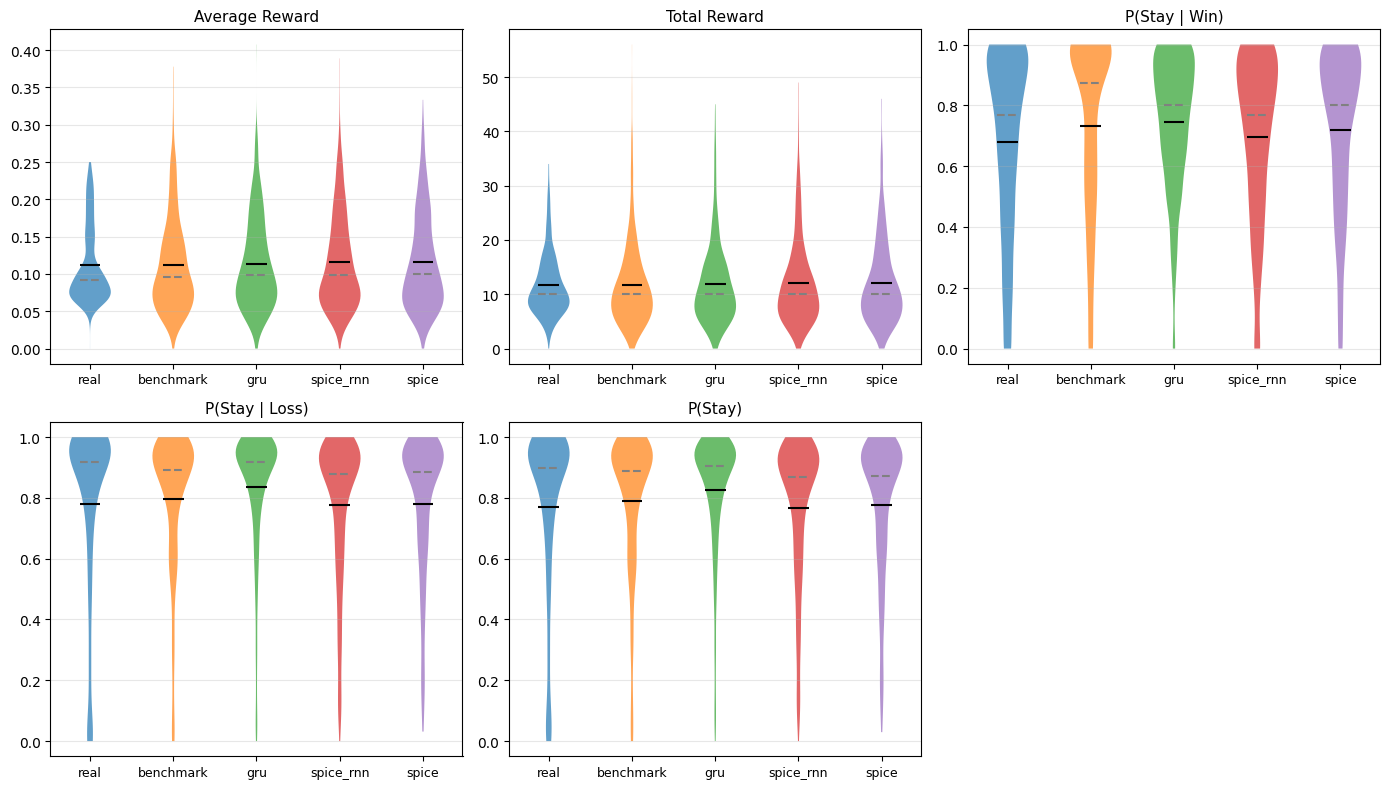

(            Average Reward      Total Reward    P(Stay | Win)  \
 Model                                                           
 real       0.112 +/- 0.051  11.720 +/- 5.731  0.678 +/- 0.300   
 benchmark  0.112 +/- 0.062  11.767 +/- 7.688  0.734 +/- 0.298   
 gru        0.113 +/- 0.061  11.846 +/- 7.427  0.747 +/- 0.223   
 spice_rnn  0.116 +/- 0.063  12.158 +/- 7.797  0.695 +/- 0.273   
 spice      0.116 +/- 0.064  12.145 +/- 7.749  0.718 +/- 0.269   
 
             P(Stay | Loss)          P(Stay)  
 Model                                        
 real       0.780 +/- 0.295  0.771 +/- 0.284  
 benchmark  0.796 +/- 0.238  0.791 +/- 0.235  
 gru        0.835 +/- 0.207  0.827 +/- 0.201  
 spice_rnn  0.775 +/- 0.238  0.768 +/- 0.236  
 spice      0.781 +/- 0.232  0.775 +/- 0.230  ,
            avg_reward  total_reward  win_stay  lose_stay    p_stay      Mean
 Model                                                                       
 benchmark    0.974658      0.978396  0.944570   0

In [22]:
analysis_generative_behavior(
    path_data_real=path_data,
    path_data_gru='data/dezfouli2019_gru.csv',
    path_data_benchmark='data/dezfouli2019_gql.csv',
    path_data_spice='data/dezfouli2019_spice.csv',
    path_data_spice_rnn='data/dezfouli2019_spice_rnn.csv',
    output_dir='results',
)

## Analysis coefficient distributions

In [23]:
# analysis_coefficients_distributions(
#     spice_model=estimator,
#     output_dir='results',
# )

## Analysis Individual Differences

In [24]:
# analysis_coefficients_individuals(
#     criterion="diag",
#     analysis="disc",  # also: "cont"
#     reference="Control",  # only necessary if analysis="disct"
    
#     path_data=path_data,
    
#     spice_model=estimator,
    
#     dir_output='results',
# )

# EXPERIMENT EMBEDDING

## Dataset setup

In [25]:
path_data = 'data/dezfouli2019_experimentid.csv'
dataset = csv_to_dataset(file = path_data)

n_actions = dataset.ys.shape[-1]
n_participants = dataset.xs[..., -1].unique().shape[0]
n_experiments = dataset.xs[..., -2].unique().shape[0]
print(f"Number of participants: {n_participants}")
print(f"Number of experiments: {n_experiments}")

test_blocks = (3, 6, 9)
dataset_train, dataset_test = split_data_along_blockdim(dataset, test_blocks)

Number of participants: 101
Number of experiments: 3


## Spice Setup

In [26]:
class SpiceEmbModel(BaseModel):
    """
    Working memory as explicit buffer of recent rewards.
    
    Key difference from value learning:
    - Stores individual past rewards (not aggregated statistics)
    - Fixed capacity (buffer size)
    - Perfect memory for items in buffer
    - Items fall out of buffer (discrete forgetting)
    """
    
    def __init__(self, reward_binary: bool = False, **kwargs):
        super().__init__(**kwargs)
        
        dropout = 0.1
        
        self.participant_embedding = self.setup_embedding(self.n_participants, self.embedding_size, dropout=dropout)
        self.experiment_embedding = self.setup_embedding(self.n_experiments, 2, dropout=dropout)
        
        # Value learning module (slow updates)
        # Can use recent reward history to modulate learning
        self.setup_module(key_module='value_reward_chosen', input_size=4+self.embedding_size+2, dropout=dropout)  # -> 21 terms
        self.setup_module(key_module='value_reward_not_chosen', input_size=3+self.embedding_size+2, dropout=dropout)  # -> 21 terms
        
        # self.setup_module(key_module='value_choice', input_size=4+self.embedding_size, dropout=dropout, include_bias=True) # -> 21 terms; bias not necessary when module is applied equally to all options
        self.setup_module(key_module='value_choice_chosen', input_size=3+self.embedding_size+2, dropout=dropout) # -> 21 terms; bias not necessary when module is applied equally to all options
        self.setup_module(key_module='value_choice_not_chosen', input_size=3+self.embedding_size+2, dropout=dropout) # -> 21 terms; bias not necessary when module is applied equally to all options
        
        self.preprocess_coefficients(reward_binary=reward_binary)
        
    def forward(self, inputs, prev_state=None):
        spice_signals = self.init_forward_pass(inputs, prev_state)

        # perform time-invariant computations
        participant_embedding = self.participant_embedding(spice_signals.participant_ids)
        experiment_embedding = self.experiment_embedding(spice_signals.experiment_ids)

        for trial in spice_signals.trials:
            
            # REWARD VALUE UPDATES
            self.call_module(
                key_module='value_reward_chosen',
                key_state='value_reward',
                action_mask=spice_signals.actions[trial],
                inputs=(
                    spice_signals.rewards[trial],
                    self.state['buffer_reward_1'],
                    self.state['buffer_reward_2'],
                    self.state['buffer_reward_3'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )

            self.call_module(
                key_module='value_reward_not_chosen',
                key_state='value_reward',
                action_mask=1-spice_signals.actions[trial],
                inputs=(
                    self.state['buffer_reward_1'],
                    self.state['buffer_reward_2'],
                    self.state['buffer_reward_3'],
                    ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )

            # CHOICE VALUE UPDATES
            # self.call_module(
            #     key_module='value_choice',
            #     key_state='value_choice',
            #     action_mask=None,
            #     inputs=(
            #         spice_signals.actions[trial],
            #         self.state['buffer_action_1'],
            #         self.state['buffer_action_2'],
            #         self.state['buffer_action_3'],
            #     ),
            #     participant_index=spice_signals.participant_ids,
            #     participant_embedding=participant_embedding,
            #     experiment_index=spice_signals.experiment_ids,
            #     experiment_embedding=experiment_embedding,
            # )
            
            self.call_module(
                key_module='value_choice_chosen',
                key_state='value_choice',
                action_mask=spice_signals.actions[trial],
                inputs=(
                    self.state['buffer_action_1'],
                    self.state['buffer_action_2'],
                    self.state['buffer_action_3'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )
            self.call_module(
                key_module='value_choice_not_chosen',
                key_state='value_choice',
                action_mask=1-spice_signals.actions[trial],
                inputs=(
                    self.state['buffer_action_1'],
                    self.state['buffer_action_2'],
                    self.state['buffer_action_3'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )

            # BUFFER UPDATES:
            # REWARD BUFFER UPDATES: Shift reward buffer for chosen action, keep for not chosen action
            # ACTION BUFFER UPDATES: Shift all buffer entries according to action
            self.state['buffer_reward_3'] = self.state['buffer_reward_2'] * spice_signals.actions[trial] + self.state['buffer_reward_3'] * (1-spice_signals.actions[trial])
            self.state['buffer_reward_2'] = self.state['buffer_reward_1'] * spice_signals.actions[trial] + self.state['buffer_reward_2'] * (1-spice_signals.actions[trial])
            self.state['buffer_reward_1'] = torch.where(spice_signals.actions[trial]==1, spice_signals.rewards[trial], 0) + torch.where(spice_signals.actions[trial]==0, self.state['buffer_reward_1'], 0)
            self.state['buffer_action_3'] = self.state['buffer_action_2']
            self.state['buffer_action_2'] = self.state['buffer_action_1']
            self.state['buffer_action_1'] = spice_signals.actions[trial]

            # compute logits for current timestep
            spice_signals.logits[trial] = self.state['value_reward'] + self.state['value_choice']

        
        spice_signals = self.post_forward_pass(spice_signals)

        return spice_signals.logits, self.get_state()
    
    def preprocess_coefficients(self, reward_binary: bool = True):
        # remove unnecessary candidate terms, e.g. polynomials of binary signals
        # if reward_binary: reward[t] = reward[t]^2 -> presence[reward[t]^2] = 0
        # accounts for ALL control signals in workingmemory model if reward is binary; else only choice signals
        
        candidate_terms = self.get_candidate_terms()
        for module in self.get_modules():
            if ('reward' in module and reward_binary) or 'choice' in module:
                control_signals = self.spice_config.library_setup[module]
                for cs in control_signals:
                    for ict, ct in enumerate(candidate_terms[module]):
                        if cs+'^' in ct:
                            self.sindy_coefficients_presence[module][..., ict] = 0
        


In [27]:
path_spice_emb = path_spice.replace('spice_', 'spice_emb_')

estimator_emb = SpiceEstimator(
    spice_class=SpiceEmbModel,
    spice_config=workingmemory.CONFIG,
    n_actions=n_actions,
    n_participants=n_participants,
    n_experiments=n_experiments,
    kwargs_spice_class={'reward_binary': True},
    
    epochs=1000,
    warmup_steps=200,
        
    ensemble_size=10,
    sindy_weight=0.1,
    sindy_alpha=0.0001,
    sindy_pruning_frequency=100,
    sindy_ensemble_pruning=0.05,
    sindy_threshold_pruning=0.01,
    sindy_library_polynomial_degree=2,
    
    save_path_spice=path_spice_emb,
    verbose=True,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    )

In [28]:
estimator_emb.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)


SPICE Training Configuration:
	SPICE-RNN training: [x]
	SINDy regularization: [x]
	Pruning (every 100 epochs): ratio test ratio=0.05, delta=0.01
	SINDy refit: [x]

Stage 1: SPICE joint training (RNN+SINDy)


AttributeError: 'SpiceSignals' object has no attribute 'rewards'

In [ ]:
estimator_emb.load_spice(path_spice_emb)

## Analysis

### Analysis model comparison

In [ ]:
# SPICE with experiment embedding
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator_emb,
)